# LLM Chains using SequentialChain, RouterChain
ways to handle and improve complex LLM use-case scenarios using chaining methods.

Login to the Hugging face and generate the API key(Access Token)

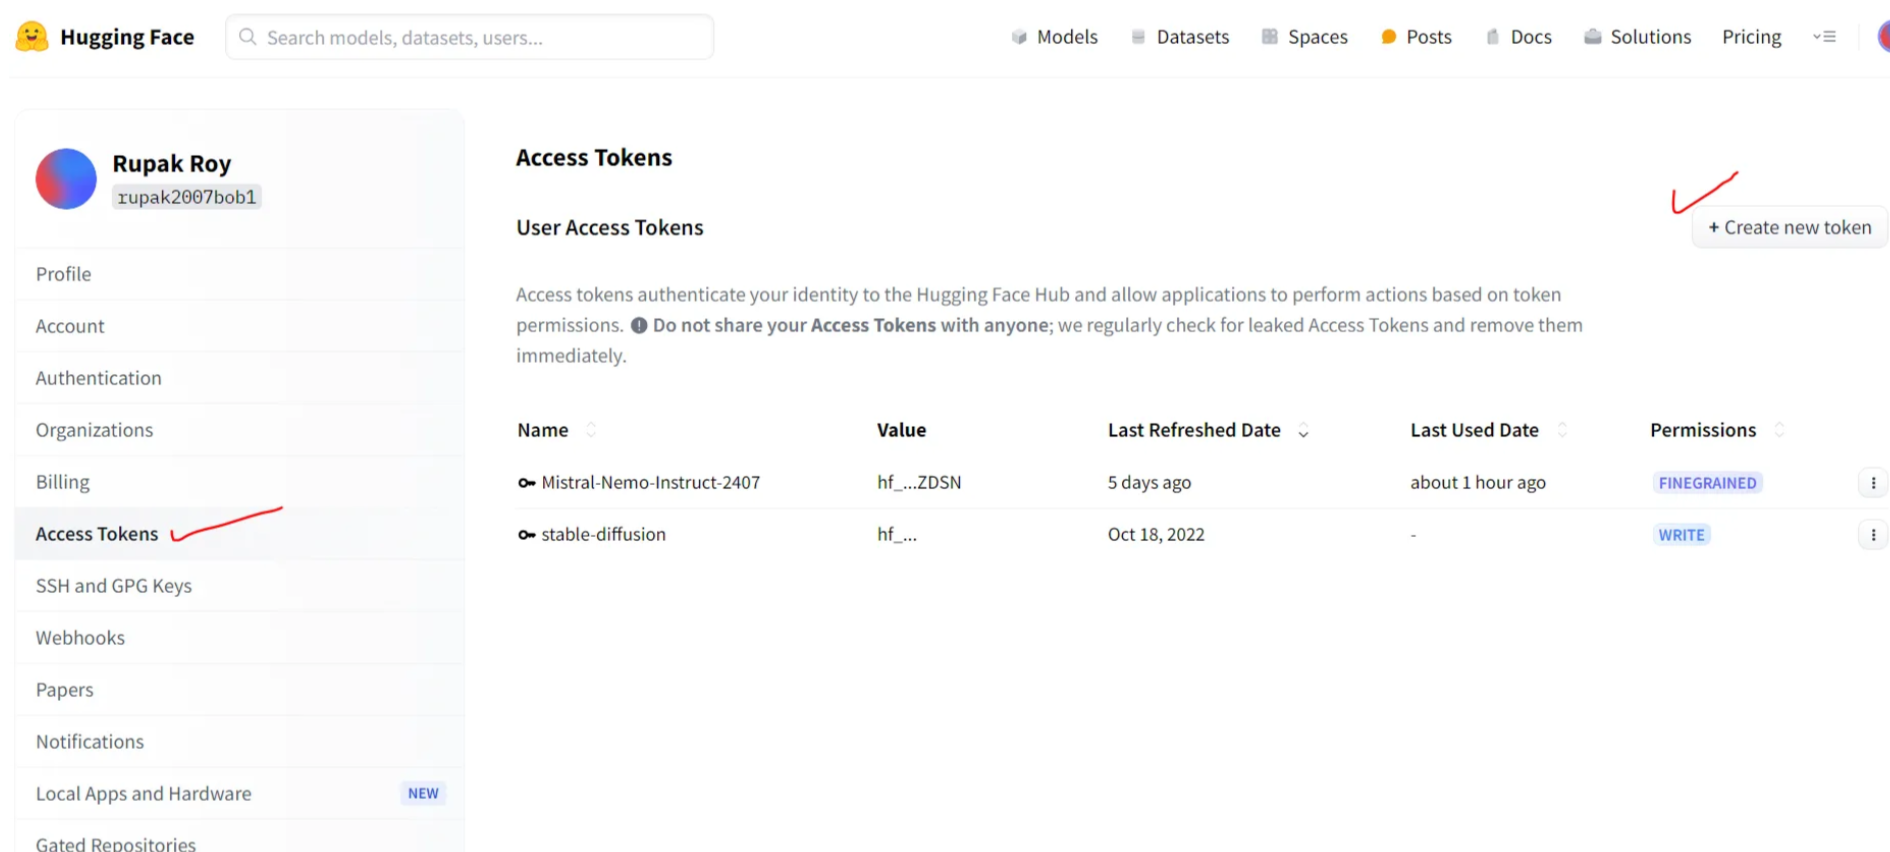



In [ ]:
from langchain_community.llms.huggingface_endpoint import HuggingFaceEndpoint
from langchain.prompts import PromptTemplate,ChatPromptTemplate
from langchain.chains import LLMChain
from langchain_core.messages import HumanMessage,SystemMessage

##################################################
#Model API call
repo_id = "mistralai/Mistral-7B-Instruct-v0.2"
llm = HuggingFaceEndpoint(
    repo_id=repo_id,
    max_length=128,
    temperature=0.5,
    huggingfacehub_api_token= "hf_yourkey")

PromptTemplate refers A prompt template consisting of a string template. It accepts a set of parameters from the user that can be used to generate a prompt for a language model. ChatPromptTempalte is used to create flexible templated prompts for chat models.

HumanMessage: HumanMessages are messages that are passed in from a human to the model. Similarly SystemMessage: Message for priming AI behavior.

In [ ]:
#------------------------------
#Prompt Format 1
prompt = PromptTemplate(
    input_variables=["product"],
    template="list me all the apple products {product}?",
)

chain1 = LLMChain(llm=llm, prompt=prompt, verbose=True) #deprecated 

chain11 = prompt | llm #instead use this new approach
print(chain1.run("laptop")) #deprecated 
results = chain11.invoke("iphone mobiles") #instead use this new approach
print(results.text)
#---------------------

In [ ]:
#---------------------------------------
#Prompt Format 2 Example
question = "what are token limits of Misteral.ai "

template = """Question: {question}?
Answer: Let's think step by step.
Give answer in bullets"""

prompt2 = PromptTemplate.from_template(template)

chain11 = LLMChain(llm=llm, prompt=prompt2, verbose=True)

t=chain11.invoke({'question':question}) #invokes saves results as dictionary 
print(t.values)
t2 = chain11.invoke("tell me a joke")
print(t2.values) #different topic but still give us answers in bullets.

#-----------------------------------------
#Prompt Format 3 Example

Review = """Les ordinateurs portables GamersTech impressionne par ses
 performances exceptionnelles et son design élégant. De sa configuration 
 matérielle robuste à un clavier RVB personnalisable et un système de 
 refroidissement efficace, il établit un équilibre parfait entre prouesses 
 de jeu et portabilité."""
Summarize = """ summarize in 20 words"""

template = """Translate the following {Review} in english and {Summarize} in bullets"""

prompt3 = PromptTemplate.from_template(template)

chain111 = LLMChain(llm=llm, prompt=prompt3, verbose=True)

t=chain111.invoke({'Review':Review,
                   'Summarize':Summarize}) 
print(t.values)

t2 = chain11.invoke("tell me a joke")
print(t2.values) #different topic but still give us answers in bullets

Next, we will try Sequential Chaining. We can think of boosting algorithm from machine learning with the goal of improving accuracy or creating a sequential pipeline where one output is the input of the other.

In [ ]:
###########################################
#Chaining two chains: Sequential Chains####
###########################################

from langchain.prompts import ChatPromptTemplate
from langchain.chains import SimpleSequentialChain
from langchain_core.output_parsers import StrOutputParser 

output_parser=StrOutputParser()

first_prompt = ChatPromptTemplate.from_template(
    "what are token limits of {product}?")
chain_one = LLMChain(llm=llm, prompt=first_prompt,output_parser= output_parser)

second_prompt = ChatPromptTemplate.from_template(
    "Write a 20 words description for the following company:{company_name}")
chain_two = LLMChain(llm=llm, prompt=second_prompt, output_parser= output_parser)

simple_chain = SimpleSequentialChain(chains=[chain_one, chain_two],verbose=True)

t = simple_chain.invoke("misterial.ai")
print(t.values)

One more complex chaining example

In [ ]:
################################################
#Crafting Chains
################################################

Review = """Les ordinateurs portables GamersTech impressionne par ses
 performances exceptionnelles et son design élégant. De sa configuration 
 matérielle robuste à un clavier RVB personnalisable et un système de 
 refroidissement efficace, il établit un équilibre parfait entre prouesses 
 de jeu et portabilité."""

# prompt template 1: translate to English
first_prompt = ChatPromptTemplate.from_template(
    "Translate the following review to english:"
    "\n\n{Review}")

# chain 1: input= Review and output= English_Review
chain_one = LLMChain(llm=llm, prompt=first_prompt,output_key="English_Review")
                   
# prompt template 2: Summarize the English review
second_prompt = ChatPromptTemplate.from_template(
    "Can you summarize the following review in 1 sentence:"
    "\n\n{English_Review}")

# chain 2: input= English_Review and output= summary
chain_two = LLMChain(llm=llm, prompt=second_prompt,output_key="summary")

# prompt template 3: translate to English
third_prompt = ChatPromptTemplate.from_template(
    "What language is the following review:\n\n{Review}")

# prompt template 4: follow up message
fourth_prompt = ChatPromptTemplate.from_template(
    "Write a follow up response to the following "
    "summary in the specified language:"
    "\n\nSummary: {summary}\n\nLanguage: {language}")

# chain 4: input= summary, language and output= followup_message
chain_four = LLMChain(llm=llm, prompt=fourth_prompt,
                      output_key="followup_message")

# chain 3: input= Review and output= language
chain_three = LLMChain(llm=llm, prompt=third_prompt,
                       output_key="language")

from langchain.chains import SequentialChain
overall_chain = SequentialChain(
    chains=[chain_one, chain_two, chain_three, chain_four],
    input_variables=["Review"],
    output_variables=["English_Review", "summary","followup_message"],
    verbose=True)

result = overall_chain.invoke(Review)

We can also craft the chains for specific tasks, that means it will be trigger whenever a relevant query/prompts executes rather then executing all of them sequentially.

It consists of:
1. Router Chain: It is responsible for selecting the next chain to call.
2. Destination Chains: Chains that the router chain can route to.
3. Default chain: Used when the router can’t decide which subchain to use.

In [ ]:
from langchain.chains.router import MultiPromptChain
from langchain.chains.router.llm_router import LLMRouterChain,RouterOutputParser
from langchain.prompts import PromptTemplate

#----- DEFINING PROMPTS ---------------------
physics_template = """You are a very smart physics professor. \
You are great at answering questions about physics in a concise\
and easy to understand manner. \
When you don't know the answer to a question you admit\
that you don't know.

Here is a question:
{input}"""


math_template = """You are a very good mathematician. \
You are great at answering math questions. \
You are so good because you are able to break down \
hard problems into their component parts,
answer the component parts, and then put them together\
to answer the broader question.

Here is a question:
{input}"""

history_template = """You are a very good historian. \
You have an excellent knowledge of and understanding of people,\
events and contexts from a range of historical periods. \
You have the ability to think, reflect, debate, discuss and \
evaluate the past. You have a respect for historical evidence\
and the ability to make use of it to support your explanations \
and judgements.

Here is a question:
{input}"""


#--------- DEFINING PROMPT TEMPLATES ------------------
prompt_infos = [
    {
        "name": "physics",
        "description": "Good for answering questions about physics",
        "prompt_template": physics_template
    },
    {
        "name": "math",
        "description": "Good for answering math questions",
        "prompt_template": math_template
    },
    {
        "name": "History",
        "description": "Good for answering history questions",
        "prompt_template": history_template
    }
]

In [ ]:
#------ DEFINING DESTINATION CHAIN ---------------
destination_chains = {}
for p_info in prompt_infos:
    name = p_info["name"]
    prompt_template = p_info["prompt_template"]
    prompt = ChatPromptTemplate.from_template(template=prompt_template)
    chain = LLMChain(llm=llm, prompt=prompt)
    destination_chains[name] = chain

destinations = [f"{p['name']}: {p['description']}" for p in prompt_infos]
destinations_str = "\n".join(destinations)

In [ ]:
#---- Creating a Multi-prompt Router Template ------
MULTI_PROMPT_ROUTER_TEMPLATE = """Given a raw text input to a \
language model select the model prompt best suited for the input. \
You will be given the names of the available prompts and a \
description of what the prompt is best suited for. \
You may also revise the original input if you think that revising\
it will ultimately lead to a better response from the language model.

<< FORMATTING >>
Return a markdown code snippet with a JSON object formatted to look like:
```json
{{{{
    "destination": string \ name of the prompt to use or "DEFAULT"
    "next_inputs": string \ a potentially modified version of the original input
}}}}
```

REMEMBER: "destination" MUST be one of the candidate prompt \
names specified below OR it can be "DEFAULT" if the input is not\
well suited for any of the candidate prompts.
REMEMBER: "next_inputs" can just be the original input \
if you don't think any modifications are needed.

<< CANDIDATE PROMPTS >>
{destinations}

<< INPUT >>
{{input}}

<< OUTPUT (remember to include the ```json)>>"""

In [ ]:
#-----Creating Router Template -------------
router_template = MULTI_PROMPT_ROUTER_TEMPLATE.format(
    destinations=destinations_str)

router_prompt = PromptTemplate(
    template=router_template,
    input_variables=["input"],
    output_parser=RouterOutputParser(),
)

router_chain = LLMRouterChain.from_llm(llm, router_prompt)

#----- DEFINING A DEFAULT CHAIN------------
default_prompt = ChatPromptTemplate.from_template("{input}")
default_chain = LLMChain(llm=llm, prompt=default_prompt)

# Binding all the chains together

In [1]:
#------- CHAINING EVERYTHING TOGETHER -------------
chain = MultiPromptChain(router_chain=router_chain,
                         destination_chains=destination_chains,
                         default_chain=default_chain, verbose=True)

p = chain.invoke("tell me about law of physics")
math = chain.invoke("what is the sum of 2+3")
history = chain.invoke("tel me about ellora")
none = chain.invoke("tell me your name")
none = chain.invoke("write me a physics and history song")

NameError: name 'MultiPromptChain' is not defined